## Statistical and Machine Learning, Fall 2024

### Week 12: Hyperparameter Optimization for Neural Networks using KerasTuner		

### Instructor: Farhad Pourkamali 

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/farhad-pourkamali/MATH6388Online/blob/main/Week12.ipynb)



### Introduction
<hr style="border:2px solid gray">

* What are hyperparameters?

    * Variables that control the training process and structure of a machine learning model.
    * Set **before** training begins and remain constant during training.
    * Have a significant impact on the model's performance.

* Types of hyperparameters:

    * **Model** hyperparameters: Affect the architecture of the model.
        * Examples: Number of hidden layers in a neural network, number of neurons per layer.
    * **Algorithm** hyperparameters: Influence the learning process itself.
        * Examples: Learning rate in gradient descent, regularization strength.
        

* Common techniques for hyperparameter optimization:

    * **Grid Search**: You define a grid of possible values for each hyperparameter, and the algorithm evaluates every single combination.
        * Simple to implement and guarantees finding the best combination within the specified grid. However, it is computationally expensive.
    * **Random Search**: Instead of exhaustively trying every combination, random search samples a predefined number of configurations from the hyperparameter space.
        * Often more efficient than Grid Search, especially when some hyperparameters are more important than others. However, it does not guarantee finding the absolute best combination. 
    * **Bayesian Optimization**: This technique uses a probabilistic model (often a Gaussian Process) to learn the relationship between hyperparameters and model performance.
        * Can be more complex to implement. The performance depends on the choice of the probabilistic model and acquisition function.
    * **Hyperband**: This is an early stopping technique designed for hyperparameter optimization. It focuses on quickly identifying and stopping poorly performing configurations, allowing more resources to be allocated to promising ones.
    
    
* Although hyperparameter optimization is rapidly advancing, comprehensive coverage of this topic in textbooks remains limited. However, a wealth of research articles provides valuable insights into this crucial aspect of machine learning.  
    * For a thorough overview of the techniques mentioned earlier, the following paper offers a particularly comprehensive and up-to-date analysis.
        * Bischl, Bernd, et al. "Hyperparameter optimization: Foundations, algorithms, best practices, and open challenges." Wiley Interdisciplinary Reviews: Data Mining and Knowledge Discovery 13.2 (2023): e1484.
        * Link: https://wires.onlinelibrary.wiley.com/doi/full/10.1002/widm.1484 (Open Access)
        
* Keras, and specifically the Keras Tuner library, provides tools for implementing hyperparameter optimization techniques. We will explore some of these techniques in this lecture.

    * Install and import the Keras Tuner:
    ```pip install -q -U keras-tuner```
    
    ```import keras_tuner as kt```



In [1]:
import keras_tuner as kt

print(kt.__version__)

1.4.7


### Problem Formulation
<hr style="border:2px solid gray">

* In a machine learning problem, a model $\hat{f}$ is obtained by configuring it with hyperparameters (HPs) $\lambda\in\boldsymbol{\Lambda}$ and training it on a data set $\mathcal{D}$: 

\begin{equation}
(\mathcal{D}, \lambda)\mapsto \hat{f}
\end{equation}

* Every predictive model should be evaluated on unseen test data to ensure an unbiased performance estimate. Assuming separate training and test data sets, $\mathcal{D}_{\text{train}}$ and $\mathcal{D}_{\text{test}}$, we define the generalization 
error of a learner as follows:

\begin{equation}
\text{Generalization Error} = \mathbb{E}_{(\mathbf{x},y)\in\mathcal{D}_{\text{test}}} \left[ L\left(\hat{f}_{\mathcal{D}_{\text{train}}, \lambda}(\mathbf{x}), y\right) \right]
\end{equation}

where $L(\cdot)$ quantifies prediction error, such as mean squared error or cross-entropy loss.

* Hyperparameter optimization algorithms seek to identify a well-performing hyperparameter configuration, $\lambda$, for a machine learning model. The search space $\boldsymbol{\Lambda}$ contains all considered hyperparameters for optimization and their respective ranges:

\begin{equation}
\boldsymbol{\Lambda}=\boldsymbol{\Lambda}_1\times \boldsymbol{\Lambda}_2\times\cdots\times \boldsymbol{\Lambda}_l
\end{equation}


where $\boldsymbol{\Lambda}_i$ is a bounded subset of the domain of the $i$-th hyperparameter, which may be continuous, discrete, or categorical.

* Example of the search space:

| Name               | Type       | Hyperparameter Ranges        | log-scale |
|--------------------|------------|------------------------------|-----------|
| learning rate      | float      | $[10^{-6}, 10^{-1}]$         | yes       |
| batch size         | integer    | $[4,64]$                           | yes       |
| activation function| categorical| relu, elu, swish, sigmoid | - |
| number of units    | integer    | $[2,16]$                           | yes       |
| number of layers   | integer    | $[1,4]$                          | no        |


* With this notation in place, let $c(\lambda)$ denote the estimated generalization error

\begin{equation}
\min_{\lambda\in\boldsymbol{\Lambda}} c(\lambda)
\end{equation}

In the following section, we will explore how Grid Search and Random Search differ in their approaches to finding optimal hyperparameters.

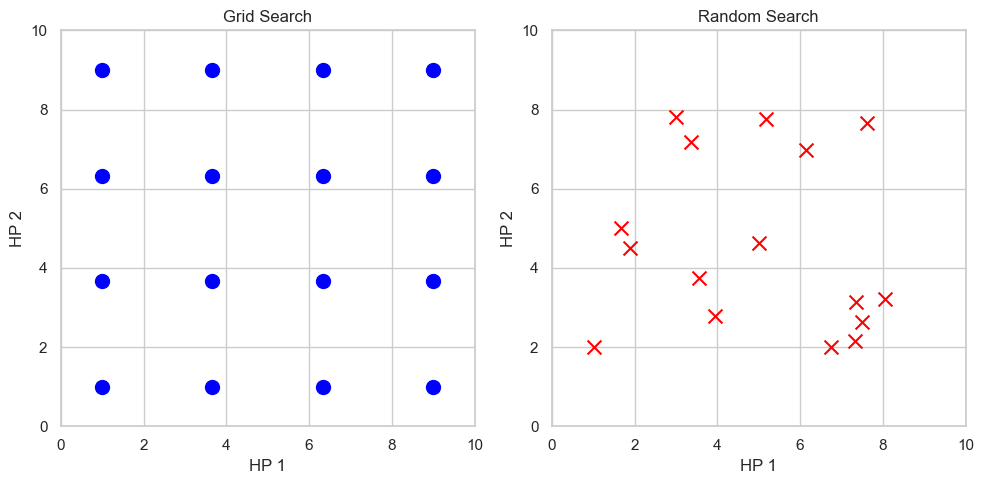

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setting the style for the plots
sns.set(style="whitegrid")

# Define the range and values for the grid search
x_values = np.linspace(1, 9, 4)  
y_values = np.linspace(1, 9, 4) 

# Create a mesh grid for grid search
X_grid, Y_grid = np.meshgrid(x_values, y_values)

# Flatten the mesh grid for easier plotting
grid_points = np.vstack([X_grid.ravel(), Y_grid.ravel()]).T

# Random search: sampling 16 random points from the interval [1, 9]
random_points = np.random.uniform(1, 9, (16, 2))

# Create the plots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot Grid Search
axes[0].scatter(grid_points[:, 0], grid_points[:, 1], color='blue', marker='o', s=100)
axes[0].set_title('Grid Search')
axes[0].set_xlabel('HP 1')
axes[0].set_ylabel('HP 2')
axes[0].set_xlim(0, 10)
axes[0].set_ylim(0, 10)

# Plot Random Search
axes[1].scatter(random_points[:, 0], random_points[:, 1], color='red', marker='x', s=100)
axes[1].set_title('Random Search')
axes[1].set_xlabel('HP 1')
axes[1].set_ylabel('HP 2')
axes[1].set_xlim(0, 10)
axes[1].set_ylim(0, 10)

# Adjust layout and show plots
plt.tight_layout()
plt.show()

### Bayesian Optimization
<hr style="border:2px solid gray">

* Bayesian Optimization is a probabilistic model-based optimization technique that is particularly effective for optimizing objective functions that are expensive to evaluate.

* A probabilistic model (usually Gaussian Processes) that approximates the objective function: $\lambda \mapsto c(\lambda)$

* Acquisition function: A strategy that guides the selection of the next point to evaluate. It balances **exploration** (sampling in uncertain areas) and **exploitation** (sampling in areas with known good performance).

* Provides a measure of uncertainty, allowing for informed decision-making in selecting new points to evaluate.


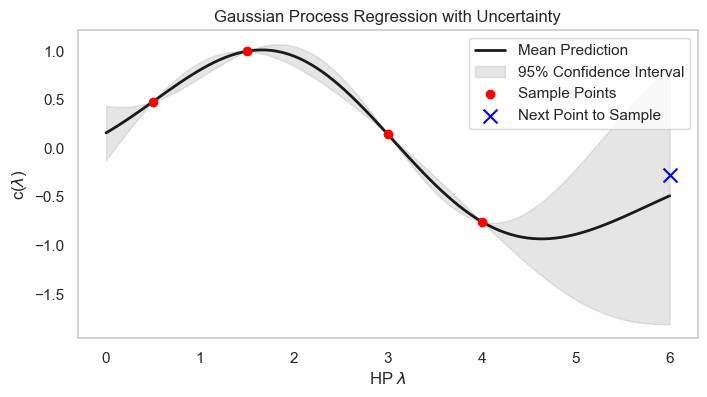

Next point to sample based on highest uncertainty (entropy): 6.00


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm

# Define the objective function (e.g., a simple sine function)
def objective_function(x):
    return np.sin(x)

# Generate sample points and evaluate the objective function
X_sample = np.array([0.5, 1.5, 3.0, 4.0])  # Initial sample points
y_sample = objective_function(X_sample)

# Fit a Gaussian Process model
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
gp.fit(X_sample.reshape(-1, 1), y_sample)

# Create a grid for predictions
X_pred = np.linspace(0, 6, 100).reshape(-1, 1)
y_pred, sigma = gp.predict(X_pred, return_std=True)

# Calculate the entropy 
def calculate_entropy(sigma):
    return 0.5 * np.log(2 * np.pi * np.e * sigma ** 2)

entropy = calculate_entropy(sigma)

# Select the point with the highest uncertainty (entropy)
next_point_index = np.argmax(entropy)
next_point = X_pred[next_point_index]

# Plot the results
plt.figure(figsize=(8, 4))

# Plot the mean prediction and uncertainty
plt.plot(X_pred, y_pred, 'k-', label='Mean Prediction', lw=2)
plt.fill_between(X_pred.ravel(), 
                 y_pred - 1.96 * sigma, 
                 y_pred + 1.96 * sigma, 
                 alpha=0.2, color='gray', label='95% Confidence Interval')
plt.scatter(X_sample, y_sample, c='red', label='Sample Points', zorder=10)
plt.scatter(next_point, objective_function(next_point), c='blue', label='Next Point to Sample', zorder=10, marker='x', s=100)

plt.title('Gaussian Process Regression with Uncertainty')
plt.xlabel(r'HP $\lambda$')
plt.ylabel(r'c($\lambda$)')
plt.legend()
plt.grid()
plt.show()

print(f"Next point to sample based on highest uncertainty (entropy): {next_point[0]:.2f}")


### Hyperband Using Successive Halving

* Hyperband is designed to optimize hyperparameters efficiently by dynamically allocating resources to promising configurations while quickly eliminating less promising ones.

* The algorithm utilizes successive halving, which involves running multiple configurations and progressively eliminating those that perform poorly after a fixed number of iterations.

* Stages:

    * Initial Sampling: Generate a large number of random hyperparameter configurations.
    * Resource Allocation: Each configuration is trained for a small number of iterations (i.e., epochs) to assess its performance.
    * Halving: After the initial evaluation, the worst-performing configurations are discarded, and the remaining configurations are trained for more iterations or epochs.
    * Iteration: This process is repeated, with the number of configurations halved and the resources allocated to the best-performing configuration.
    
<img src="https://github.com/farhad-pourkamali/MATH6388Online/blob/main/images/hyperband.png?raw=true" width=600>


In [4]:
import tensorflow as tf
from tensorflow import keras
import keras_tuner as kt


In [5]:
# Fashion MNIST

(img_train, label_train), (img_test, label_test) = keras.datasets.fashion_mnist.load_data()


In [6]:
print(img_train.shape, img_test.shape)

(60000, 28, 28) (10000, 28, 28)


In [7]:
label_train

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

In [8]:
# Normalize pixel values between 0 and 1

img_train = img_train.astype('float32') / 255.0

img_test = img_test.astype('float32') / 255.0

* Hypermodel: A model you set up specifically for hyperparameter tuning. It includes both the model architecture and the definition of the hyperparameter search space.

* Create a function that takes hyperparameters as input and returns a compiled model.
    * Inside the function, use the input hyperparameters to define the model's architecture (e.g., number of layers, units per layer).
    * hp.Int(): Defines an integer hyperparameter
    * hp.Float(): Defines a floating-point hyperparameter
    * hp.Choice(): Defines a hyperparameter that can take one of a set of discrete values
    * hp.Boolean(): Defines a boolean hyperparameter (True or False)

In [16]:
def model_builder(hp):
    """
    Builds a Keras Sequential model with hyperparameter tuning.

    This function defines a simple neural network model for image classification, 
    where the number of units in the first dense layer and the learning rate of 
    the optimizer are tunable hyperparameters.

    Args:
     hp: A Keras Tuner HyperParameters object.

    Returns:
     A compiled Keras Sequential model.
    """
    model = keras.Sequential()
    model.add(keras.layers.Flatten(input_shape=(28, 28)))

    # Tune the number of units in the first Dense layer
    # Choose an optimal value between 32-512
    hp_units = hp.Int('units', min_value=32, max_value=512, step=32)
    model.add(keras.layers.Dense(units=hp_units, activation='relu'))

    model.add(keras.layers.Dense(10))

    # Tune the learning rate for the optimizer
    # Choose an optimal value from 0.01, 0.001, or 0.0001
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
                loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                metrics=['accuracy'])

    return model

Instantiate the tuner to perform the hypertuning. The Keras Tuner has four tuners available: `RandomSearch`, `Hyperband`, `BayesianOptimization`, and `Sklearn`. In this lecture, we use the `Hyperband` tuner.

Documentation: https://keras.io/api/keras_tuner/tuners/hyperband/


In [10]:
tuner = kt.Hyperband(model_builder,
                     objective='val_accuracy',
                     max_epochs=5, # the maximum number of epochs to train 
                     directory='my_dir',
                     project_name='intro_to_kt')

Reloading Tuner from my_dir/intro_to_kt/tuner0.json


2024-10-29 11:34:21.691124: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Max
2024-10-29 11:34:21.691180: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 64.00 GB
2024-10-29 11:34:21.691196: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 24.00 GB
2024-10-29 11:34:21.691242: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2024-10-29 11:34:21.691276: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Run the hyperparameter search. The arguments for the search method are the same as those used for `tf.keras.model.fit`.

In [11]:
tuner.search(img_train, label_train, epochs=10, validation_split=0.2)


Trial 30 Complete [00h 01m 06s]
val_accuracy: 0.8524166941642761

Best val_accuracy So Far: 0.8916666507720947
Total elapsed time: 00h 17m 42s


In [12]:
# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# num_trials=1:  This argument specifies that you want to 
# retrieve only the top 1 best hyperparameter set.


print(f"""
The hyperparameter search is complete. The optimal number of units in the first densely-connected
layer is {best_hps.get('units')} and the optimal learning rate for the optimizer
is {best_hps.get('learning_rate')}.
""")


The hyperparameter search is complete. The optimal number of units in the first densely-connected
layer is 320 and the optimal learning rate for the optimizer
is 0.001.



Find the optimal number of epochs to train the model with the hyperparameters obtained from the search.


In [13]:
# Build the model with the optimal hyperparameters and train it on the data for 50 epochs
model = tuner.hypermodel.build(best_hps)
history = model.fit(img_train, label_train, epochs=50, validation_split=0.2)

val_acc_per_epoch = history.history['val_accuracy']
best_epoch = val_acc_per_epoch.index(max(val_acc_per_epoch)) + 1
print('Best epoch: %d' % (best_epoch,))

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7827 - loss: 0.6200 - val_accuracy: 0.8378 - val_loss: 0.4490
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8621 - loss: 0.3796 - val_accuracy: 0.8679 - val_loss: 0.3604
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8771 - loss: 0.3359 - val_accuracy: 0.8673 - val_loss: 0.3693
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8849 - loss: 0.3077 - val_accuracy: 0.8763 - val_loss: 0.3438
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8932 - loss: 0.2900 - val_accuracy: 0.8691 - val_loss: 0.3695
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8977 - loss: 0.2721 - val_accuracy: 0.8860 - val_loss: 0.3264
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9052 - loss: 0.2515 - val_accuracy: 0.8831 - val_loss: 0.3216
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9087 - loss: 0.2455 - 

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9695 - loss: 0.0785 - val_accuracy: 0.8923 - val_loss: 0.5439
Best epoch: 22


Re-instantiate the hypermodel and train it with the optimal number of epochs from above.


In [14]:
hypermodel = tuner.hypermodel.build(best_hps)

# Retrain the model
hypermodel.fit(img_train, label_train, epochs=best_epoch, validation_split=0.2)

# Evaluate on the test data 
eval_result = hypermodel.evaluate(img_test, label_test)

print("[test loss, test accuracy]:", eval_result)

Epoch 1/22
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7793 - loss: 0.6187 - val_accuracy: 0.8571 - val_loss: 0.4079
Epoch 2/22
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8637 - loss: 0.3769 - val_accuracy: 0.8723 - val_loss: 0.3559
Epoch 3/22
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8776 - loss: 0.3331 - val_accuracy: 0.8733 - val_loss: 0.3488
Epoch 4/22
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8879 - loss: 0.3054 - val_accuracy: 0.8665 - val_loss: 0.3644
Epoch 5/22
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8928 - loss: 0.2949 - val_accuracy: 0.8813 - val_loss: 0.3288
Epoch 6/22
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8969 - loss: 0.2748 - val_accuracy: 0.8899 - val_loss: 0.3163
Epoch 7/22
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9038 - loss: 0.2546 - val_accuracy: 0.8869 - val_loss: 0.3214
Epoch 8/22
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9098 - loss: 0.2434 - 